In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [31]:
import sys
!{sys.executable} -m pip install seaborn

In [24]:
#Filter only a job in the US
df_US = df[df['job_country']=='United States']

#Then breakout the list of the job
df_skills = df_US.explode('job_skills')

#To see if the job skills have been breaking out
#df_skills[['job_title', 'job_skills']]

#Group the skills count
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

#Change df_skills_group from series to dataframe because it's easier to manipulate
df_skills_count = df_skills_count.reset_index(name = 'skill_count')

#Sort value by skills count from high to low
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [11]:
#Make a job title short to be a list
job_titles = df_skills_count['job_title_short'].unique().tolist()

#Select only top three in the list using slicing and also use sort function to make the list in alphabet order
job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

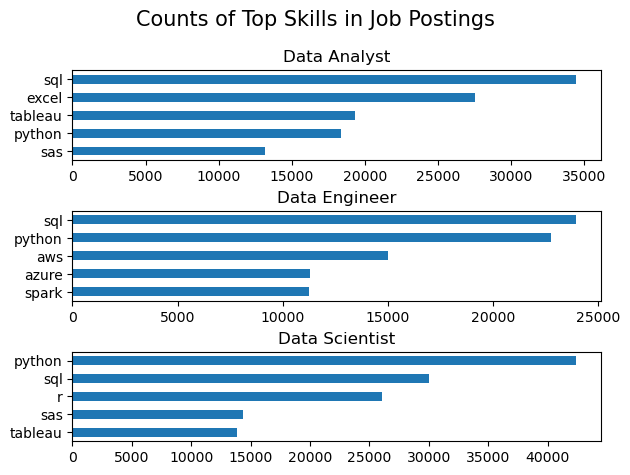

In [20]:
#plotting the graph - need only 1 column
fig, ax = plt.subplots(len(job_titles), 1)

#We need to loop in the list
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_count', ax=ax[i], title = job_title)
    #clean up the graph
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

    fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
    #Fix the overlap
    fig.tight_layout(h_pad = 0.5)
    
plt.show()


In [ ]:
#Create a graph show percentage of skills instead of count
# % of skill in job postings = (skill counts in job posting)/(total counts of job postings)
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name = 'job_total')
df_job_title_count

,job_title_short,job_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


In [28]:
# mearge two dataframe
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how = 'left', on='job_title_short')
df_skills_perc['skill_perc'] = 100 * df_skills_perc['skill_count']/df_skills_perc['job_total']
df_skills_perc

,job_skills,job_title_short,skill_count,job_total,skill_perc
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


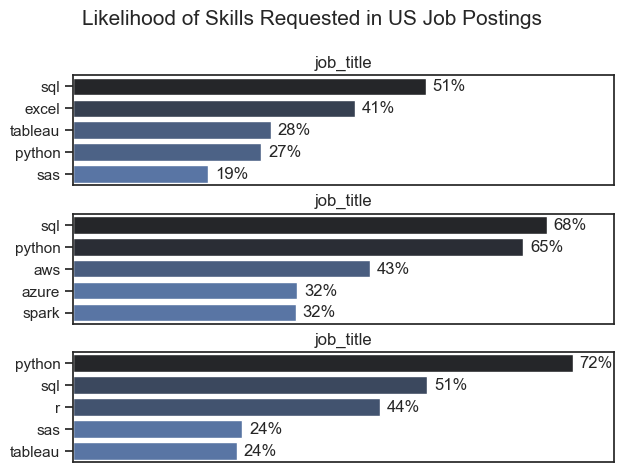

In [45]:
#plotting the graph - need only 1 column
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style = 'ticks')

#We need to loop in the list
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    #df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_perc', ax=ax[i], title = job_title)
    #Change for seaborn plot instead
    sns.barplot(data = df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue ='skill_count', palette = 'dark:b_r')
    #clean up the graph
    ax[i].set_title('job_title')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0, 78)

    #To add number of percentage to the plot, we need to loop through the df_plot to get the number
    for n, v in enumerate (df_plot['skill_perc']):
        # v +1 means add space to the number
        # v = 'center' means vertical number at the center
        ax[i].text(v + 1, n, f'{v:.0f}%', va = 'center')

    # Remove all the x ticks but keep the ticks of the last plot
    if i != len('job_titles') - 1:
        ax[i].set_xticks([])

    fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
    #Fix the overlap
    fig.tight_layout(h_pad = 0.5)
    
plt.show()